In [18]:

path = '/home/apollo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [20]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
# import dabest

from statsmodels.stats.proportion import proportions_chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib widget

# import helper_functions as hf


In [21]:

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")


In [22]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [23]:

import statsmodels.api as sm
import statsmodels.formula.api as smf


In [24]:
os.chdir(tables_path + '/figure_3/')

filename = 'Figure_Ripple_PhasePhaseCoupling_RippleEpochs.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]
df

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]

# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df

,rat,session,side,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,0.898466,-0.087752,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,0.811789,-0.200425,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,0.734627,-0.257894,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,0.637557,-0.315600,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,0.545145,-0.413795,5.0
...,...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,0.809823,0.199868,2.0
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,0.564736,0.615324,3.0
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,0.839078,0.179774,1.0
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,0.583716,0.612159,2.0


In [4]:

os.chdir(tables_path + '/figure_3/')

filename = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]
df

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]

# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,side,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,0.692846,-0.047308,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,0.584654,-0.108481,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,0.500051,-0.181145,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,0.415421,-0.230551,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,0.343567,-0.356099,5.0
...,...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,0.670832,0.130364,2.0
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,0.527790,0.261849,3.0
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,0.681096,0.120046,1.0
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,0.524224,0.267637,2.0


In [13]:
df['shanks_distance_units']

0      1.0
1      2.0
2      3.0
3      4.0
4      5.0
      ... 
460    2.0
461    3.0
462    1.0
463    2.0
464    1.0
Name: shanks_distance_units, Length: 465, dtype: float64

In [5]:
np.sum(df.side == 'ipsi')

np.int64(220)

In [6]:
np.sum(df.side == 'contra')

np.int64(245)

In [7]:
np.sum(df.side == 'contra')+np.sum(df.side == 'ipsi')

np.int64(465)

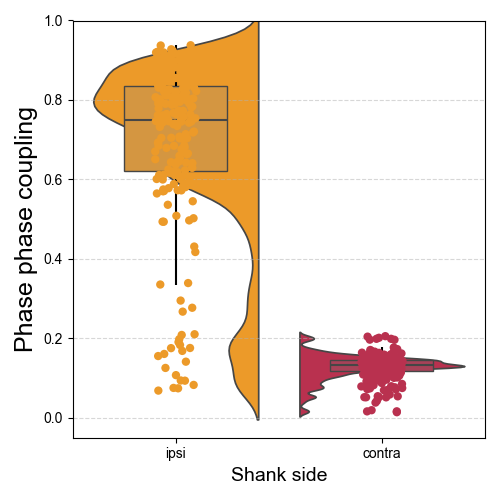

In [25]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="phase_phase_coupling", order=["ipsi", "contra"],
              palette=my_pal,size=6,alpha=1)
# # sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
# #               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
# #               err_kws={'linewidth': 6},linewidth=2,markersize=10)

# # Create the boxplot
box = sns.boxplot(data=df, x='side', hue="side", y='phase_phase_coupling',
            order=['ipsi','contra'], showfliers=False, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

ax=sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='phase_phase_coupling',
               palette=my_pal,fill=True,inner = None,split=True,
               density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Phase phase coupling',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_3/')
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.svg'
fig_name = 'Figure_Ripple_PhasePhaseCoupling_RippleEvents.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



In [26]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "phase_phase_coupling ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         phase_phase_coupling
No. Observations:         465             Method:                     REML                
No. Groups:               4               Scale:                      0.0180              
Min. group size:          36              Log-Likelihood:             262.0125            
Max. group size:          198             Converged:                  Yes                 
Mean group size:          116.2                                                           
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.677    0.040  16.755 0.000  0.598  0.756
C(side, Treatment(referenc

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [10]:
result.pvalues

Intercept                                         2.004567e-204
C(side, Treatment(reference='ipsi'))[T.contra]     0.000000e+00
rat Var                                            5.872910e-01
session Var                                        2.529713e-01
dtype: float64

In [28]:
# Print summary of the model
print('coeff coefficient = ' + str(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]))
print('coeff in % of intercept = ' + str(100*(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]/result.fe_params['Intercept'])) + ' %')


coeff coefficient = -0.5677311082301948
coeff in % of intercept = -83.86915212603495 %


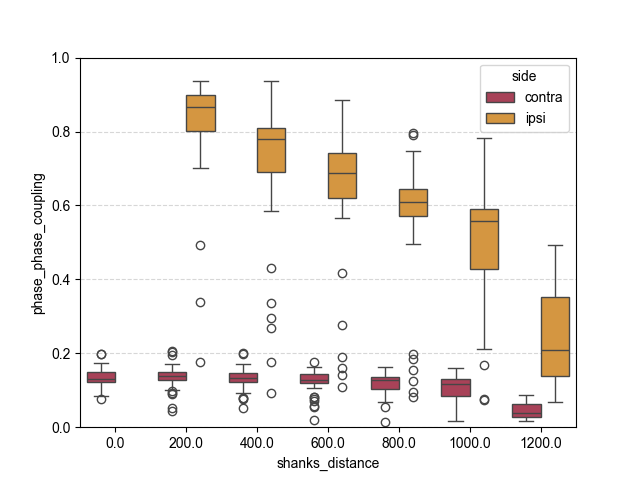

ClipPath elements deleted.
File saved.


In [23]:
my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

plt.close('all')
sns.boxplot(data=df, hue='side', y="phase_phase_coupling",x='shanks_distance',palette=my_pal)
plt.ylim([0,1])
plt.grid(linestyle='--',alpha=0.5,axis='y')

os.chdir(figures_path + '/figure_3/')
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal_AcrossDistances.svg'
fig_name = 'Figure_Ripple_PhasePhaseCoupling_RippleEvents_AcrossDistances.svg'

plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
hf.delete_clip_path(fig_name)


In [10]:
# I'm doing this so we can interpret the coefficient as change in 200 micrometer unit.


In [12]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "phase_phase_coupling ~ C(side, Treatment(reference='ipsi')) * shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                     Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                phase_phase_coupling
No. Observations:                 465                    Method:                            REML                
No. Groups:                       4                      Scale:                             0.0064              
Min. group size:                  36                     Log-Likelihood:                    488.8143            
Max. group size:                  198                    Converged:                         Yes                 
Mean group size:                  116.2                                                                         
----------------------------------------------------------------------------------------------------------------
                                                                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [26]:
result.pvalues

Intercept                                                               4.817578e-126
C(side, Treatment(reference='ipsi'))[T.contra]                           0.000000e+00
shanks_distance_units                                                    1.034903e-69
C(side, Treatment(reference='ipsi'))[T.contra]:shanks_distance_units     3.123634e-40
rat Var                                                                  2.252544e-01
session Var                                                              9.996330e-01
dtype: float64

In [14]:
import statsmodels.api as sm
data_ipsi = df[df['side'] == 'ipsi']

# Define the formula for the mixed-effects model
formula = "phase_phase_coupling ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_ipsi,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: phase_phase_coupling
No. Observations: 220     Method:             REML                
No. Groups:       4       Scale:              0.0119              
Min. group size:  22      Log-Likelihood:     159.4508            
Max. group size:  90      Converged:          Yes                 
Mean group size:  55.0                                            
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               0.705    0.034  21.037 0.000  0.639  0.771
shanks_distance_units  -0.076    0.006 -13.578 0.000 -0.087 -0.065
rat Var                 0.002    0.033                            
session Var             0.003    0.029                            

shanks_distance_units coefficient = -0.07567744674683877
shanks_distance_uni

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [28]:
result.pvalues

Intercept                6.290623e-47
shanks_distance_units    3.174989e-47
rat Var                  1.247198e-01
session Var              7.269044e-01
dtype: float64

In [29]:
import statsmodels.api as sm
data_contra = df[df['side'] == 'contra']

# Define the formula for the mixed-effects model
formula = "phase_phase_coupling ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_contra,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: phase_phase_coupling
No. Observations: 245     Method:             REML                
No. Groups:       4       Scale:              0.0008              
Min. group size:  14      Log-Likelihood:     509.9806            
Max. group size:  108     Converged:          Yes                 
Mean group size:  61.2                                            
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.134    0.009 14.627 0.000  0.116  0.152
shanks_distance_units   -0.006    0.001 -5.346 0.000 -0.009 -0.004
rat Var                  0.000    0.009                           
session Var              0.000    0.001                           

shanks_distance_units coefficient = -0.006466079360235781
shanks_distance_un

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [30]:
result.pvalues

Intercept                1.892921e-48
shanks_distance_units    8.979749e-08
rat Var                  2.838081e-01
session Var              1.000000e+00
dtype: float64

In [20]:

os.chdir(tables_path + '/figure_3/')

filename = 'Figure_Ripple_CrossCorrelation_Filtered_Signal.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]
df

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df

df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,side,shank_1,shank_2,shanks_distance,max_correlation,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,4.086508e+06,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,3.653658e+06,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,3.221406e+06,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,2.708363e+06,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,2.347948e+06,5.0
...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,3.652647e+06,2.0
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,2.651016e+06,3.0
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,3.773761e+06,1.0
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,2.706972e+06,2.0


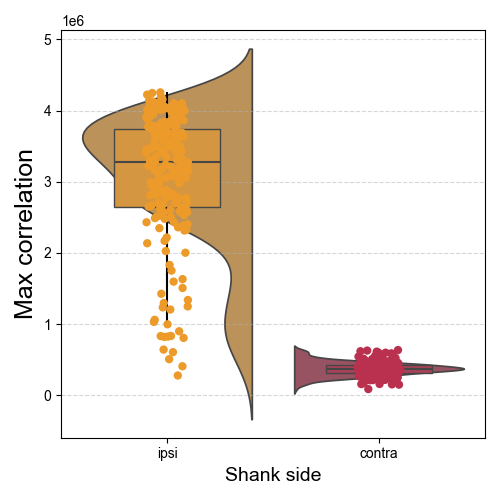

In [21]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="max_correlation", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)

# # Create the boxplot
box = sns.boxplot(data=df, x='side', hue="side", y='max_correlation',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='max_correlation',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1)

plt.ylabel('Max correlation',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
# plt.ylim(bottom=0)
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_3/')
fig_name = 'Figure_Ripple_CrossCorrelation_Filtered_Signal.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


In [22]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "max_correlation ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())



                                      Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 max_correlation  
No. Observations:                   465                     Method:                             REML             
No. Groups:                         4                       Scale:                              345109256409.1721
Min. group size:                    36                      Log-Likelihood:                     -6817.3157       
Max. group size:                    198                     Converged:                          Yes              
Mean group size:                    116.2                                                                        
-----------------------------------------------------------------------------------------------------------------
                                                    Coef.       Std.Err.     z    P>|z|    [0.025       0.975]   
------------

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [23]:
result.pvalues

Intercept                                         2.654999e-116
C(side, Treatment(reference='ipsi'))[T.contra]     0.000000e+00
rat Var                                            2.480973e-01
session Var                                        8.677041e-01
dtype: float64

In [ ]:
-2.71

In [24]:
# Print summary of the model
print('coeff coefficient = ' + str(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]))
print('coeff in % of intercept = ' + str(100*(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]/result.fe_params['Intercept'])) + ' %')


coeff coefficient = -2708388.7220484684
coeff in % of intercept = -89.37865886951259 %


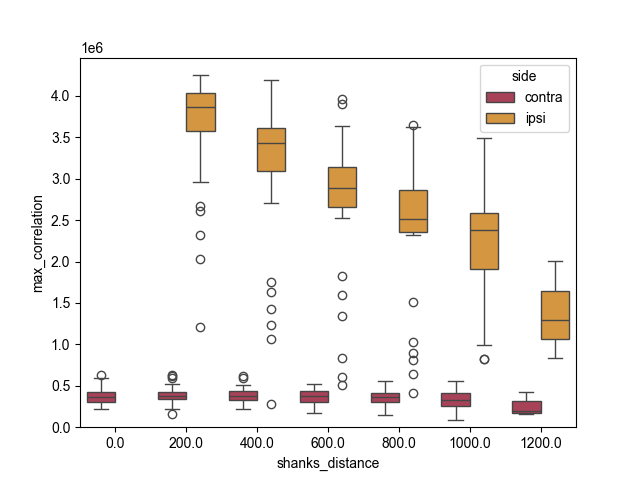

In [16]:

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

plt.close('all')
sns.boxplot(data=df,hue='side',x='shanks_distance',y='max_correlation',palette=my_pal)
plt.ylim(bottom=0)

os.chdir(figures_path + '/figure_3/')
fig_name = 'Figure_Ripple_CrossCorrelation_Filtered_Signal_AcrossDistances.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


In [17]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "max_correlation ~ C(side, Treatment(reference='ipsi'))*shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
result.fe_params['shanks_distance_units']/10**6


                                                 Mixed Linear Model Regression Results
Model:                                    MixedLM                         Dependent Variable:                         max_correlation  
No. Observations:                         465                             Method:                                     REML             
No. Groups:                               4                               Scale:                                      199512678940.5647
Min. group size:                          36                              Log-Likelihood:                             -6669.3896       
Max. group size:                          198                             Converged:                                  Yes              
Mean group size:                          116.2                                                                                        
-------------------------------------------------------------------------------------------------

-0.4163827420535847

In [18]:
result.pvalues

Intercept                                                               7.709868e-193
C(side, Treatment(reference='ipsi'))[T.contra]                           0.000000e+00
shanks_distance_units                                                    8.001314e-75
C(side, Treatment(reference='ipsi'))[T.contra]:shanks_distance_units     1.244475e-46
rat Var                                                                  2.488870e-01
session Var                                                              5.324651e-01
dtype: float64

In [19]:

import statsmodels.api as sm
data_ipsi = df[df['side'] == 'ipsi']

# Define the formula for the mixed-effects model
formula = "max_correlation ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_ipsi,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']/10**6))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


                         Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         max_correlation  
No. Observations:         220             Method:                     REML             
No. Groups:               4               Scale:                      314676738615.3627
Min. group size:          22              Log-Likelihood:             -3208.0850       
Max. group size:          90              Converged:                  Yes              
Mean group size:          55.0                                                         
---------------------------------------------------------------------------------------
                           Coef.        Std.Err.     z    P>|z|    [0.025      0.975]  
---------------------------------------------------------------------------------------
Intercept                  3986651.105 265120.054  15.037 0.000 3467025.348 4506276.862
shanks_distance_units      -407990.011  28616.078 -14.257

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [20]:
result.fe_params['shanks_distance_units']/10**6


-0.4079900109591123

In [60]:
result.pvalues

Intercept                4.191874e-51
shanks_distance_units    4.033710e-46
rat Var                  2.507109e-01
session Var              4.111724e-01
dtype: float64

In [23]:

import statsmodels.api as sm
data_contra = df[df['side'] == 'contra']

# Define the formula for the mixed-effects model
formula = "max_correlation ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_contra,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']/10**6))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                      Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       max_correlation
No. Observations:         245           Method:                   REML           
No. Groups:               4             Scale:                    6515701139.7045
Min. group size:          14            Log-Likelihood:           -3103.8328     
Max. group size:          108           Converged:                Yes            
Mean group size:          61.2                                                   
---------------------------------------------------------------------------------
                          Coef.       Std.Err.   z    P>|z|   [0.025     0.975]  
---------------------------------------------------------------------------------
Intercept                 387520.283 23181.984 16.716 0.000 342084.429 432956.137
shanks_distance_units      -9442.419  3434.748 -2.749 0.006 -16174.400  -2710.437
rat Var               1235076908.235 2

In [22]:
result.pvalues

Intercept                9.948484e-63
shanks_distance_units    5.976160e-03
rat Var                  4.608931e-01
session Var              2.316408e-01
dtype: float64